Fitting 10 folds for each of 72 candidates, totalling 720 fits


C:\Users\13258\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:29:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


最佳参数： {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
AUC: 0.9673
Accuracy: 0.9159
Sensitivity (Recall): 0.9627
F1 Score: 0.9029
Brier Score: 0.0628
Confusion Matrix:
 [[3678  483]
 [ 106 2738]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93      4161
           1       0.85      0.96      0.90      2844

    accuracy                           0.92      7005
   macro avg       0.91      0.92      0.91      7005
weighted avg       0.92      0.92      0.92      7005



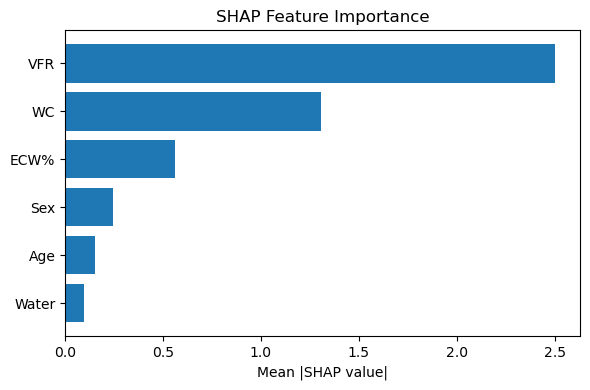

In [1]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, 
    accuracy_score, recall_score, f1_score, brier_score_loss
)

# 中文列名
features_zh = [ '身体水分量',  '细胞外液率', '内脏脂肪等级', 'XB0000','NL0000','腰围']
target = '脂肪肝'

# 英文映射
feature_map = {
   '身体水分量': 'Water','细胞外液率': 'ECW%', '内脏脂肪等级': 'VFR', 
    'XB0000': 'Sex', 'NL0000': 'Age' ,'腰围':'WC'
}

# 数据读取与清洗
data = pd.read_excel(r"D:\NPAR\人体成分分析\最终试用版.xlsx")
df = data[features_zh + [target]].replace(['-----', '****', '***', '###', 'NA', 'NaN'], pd.NA)
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df[features_zh]
y = df[target]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 参数网格
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 网格搜索 + 十折交叉验证
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, 
                           scoring='roc_auc', cv=10, verbose=1, n_jobs=-1)

# 训练
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 预测
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 评估指标
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_prob)

print("最佳参数：", grid_search.best_params_)
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 使用 SHAP 的 TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)

# 使用英文列名替换
features_en = [feature_map[col] for col in features_zh]

# 计算每个特征的平均绝对 SHAP 值
shap_df = pd.DataFrame({
    'Feature': features_en,
    'SHAP_MeanAbs': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_MeanAbs', ascending=False)

# 保存为 Excel 表格
shap_df.to_excel("XGBshap_feature_importance_en.xlsx", index=False)

# SHAP summary plot（分布图）
plt.figure(figsize=(4, 3))
shap.summary_plot(shap_values, X_train, feature_names=features_en, show=False)
plt.tight_layout()
plt.savefig("XGBshap_summary_plot_en.png", dpi=600)
plt.close()
plt.show()

# 绘制 SHAP 平均绝对值条形图
plt.figure(figsize=(6, 4))
plt.barh(shap_df['Feature'], shap_df['SHAP_MeanAbs'])
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance")
plt.savefig("XGBshap_bar_plot_en.png", dpi=600)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Fitting 10 folds for each of 72 candidates, totalling 720 fits


C:\Users\13258\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:38:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


最佳参数： {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
AUC: 0.9673
Accuracy: 0.9159
Sensitivity (Recall): 0.9627
F1 Score: 0.9029
Brier Score: 0.0628
Confusion Matrix:
 [[3678  483]
 [ 106 2738]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93      4161
           1       0.85      0.96      0.90      2844

    accuracy                           0.92      7005
   macro avg       0.91      0.92      0.91      7005
weighted avg       0.92      0.92      0.92      7005



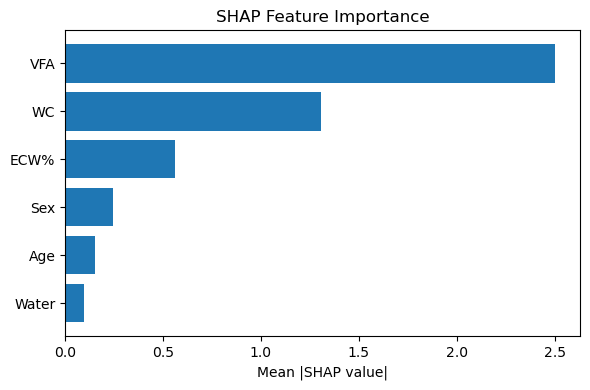

In [1]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, 
    accuracy_score, recall_score, f1_score, brier_score_loss
)

# 中文列名
features_zh = [ '身体水分量',  '细胞外液率', '内脏脂肪等级', 'XB0000','NL0000','腰围']
target = '脂肪肝'

# 英文映射
feature_map = {
   '身体水分量': 'Water','细胞外液率': 'ECW%', '内脏脂肪等级': 'VFA', 
    'XB0000': 'Sex', 'NL0000': 'Age' ,'腰围':'WC'
}

# 数据读取与清洗
data = pd.read_excel(r"D:\NPAR\人体成分分析\最终试用版.xlsx")
df = data[features_zh + [target]].replace(['-----', '****', '***', '###', 'NA', 'NaN'], pd.NA)
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df[features_zh]
y = df[target]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 参数网格
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 网格搜索 + 十折交叉验证
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, 
                           scoring='roc_auc', cv=10, verbose=1, n_jobs=-1)

# 训练
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 预测
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 评估指标
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_prob)

print("最佳参数：", grid_search.best_params_)
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 使用 SHAP 的 TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)

# 使用英文列名替换
features_en = [feature_map[col] for col in features_zh]

# 计算每个特征的平均绝对 SHAP 值
shap_df = pd.DataFrame({
    'Feature': features_en,
    'SHAP_MeanAbs': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_MeanAbs', ascending=False)

# 保存为 Excel 表格
shap_df.to_excel("XGBshap_feature_importance_en.xlsx", index=False)

# SHAP summary plot（分布图）
plt.figure(figsize=(4, 3))
shap.summary_plot(shap_values, X_train, feature_names=features_en, show=False)
plt.tight_layout()
plt.savefig("XGBshap_summary_plot_en.png", dpi=600)
plt.close()
plt.show()

# 绘制 SHAP 平均绝对值条形图
plt.figure(figsize=(6, 4))
plt.barh(shap_df['Feature'], shap_df['SHAP_MeanAbs'])
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance")
plt.savefig("XGBshap_bar_plot_en.png", dpi=600)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Fitting 10 folds for each of 72 candidates, totalling 720 fits


C:\Users\13258\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:12:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


最佳参数： {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
AUC: 0.9673
Accuracy: 0.9159
Sensitivity (Recall): 0.9627
F1 Score: 0.9029
Brier Score: 0.0628
Confusion Matrix:
 [[3678  483]
 [ 106 2738]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93      4161
           1       0.85      0.96      0.90      2844

    accuracy                           0.92      7005
   macro avg       0.91      0.92      0.91      7005
weighted avg       0.92      0.92      0.92      7005



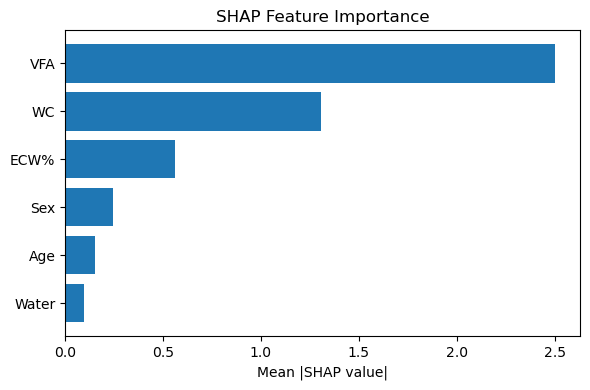

In [3]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, 
    accuracy_score, recall_score, f1_score, brier_score_loss
)

# 中文列名
features_zh = [ '身体水分量',  '细胞外液率', '内脏脂肪等级', 'XB0000','NL0000','腰围']
target = '脂肪肝'

# 英文映射
feature_map = {
   '身体水分量': 'Water','细胞外液率': 'ECW%', '内脏脂肪等级': 'VFA', 
    'XB0000': 'Sex', 'NL0000': 'Age' ,'腰围':'WC'
}

features_en = [feature_map[col] for col in features_zh]

# 数据读取与清洗
data = pd.read_excel(r"D:\NPAR\人体成分分析\最终试用版.xlsx")
df = data[features_zh + [target]].replace(['-----', '****', '***', '###', 'NA', 'NaN'], pd.NA)
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df[features_zh]
y = df[target]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 参数网格
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 网格搜索 + 十折交叉验证
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, 
                           scoring='roc_auc', cv=10, verbose=1, n_jobs=-1)

# 训练
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 预测
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 评估指标
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_prob)

print("最佳参数：", grid_search.best_params_)
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 使用 SHAP 的 TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)

# 使用英文列名替换
features_en = [feature_map[col] for col in features_zh]

# 计算每个特征的平均绝对 SHAP 值
shap_df = pd.DataFrame({
    'Feature': features_en,
    'SHAP_MeanAbs': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_MeanAbs', ascending=False)

# 保存为 Excel 表格
shap_df.to_excel("XGBshap_feature_importance_en.xlsx", index=False)

# SHAP summary plot（分布图）
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values, X_train, feature_names=features_en, show=False, plot_size=(6, 4))
plt.tight_layout()
plt.savefig("XGBshap_summary_plot_en.png", dpi=600)
plt.close()

# 绘制 SHAP 平均绝对值条形图
plt.figure(figsize=(6, 4))
plt.barh(shap_df['Feature'], shap_df['SHAP_MeanAbs'])
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance")
plt.savefig("XGBshap_bar_plot_en.png", dpi=600)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Fitting 10 folds for each of 8 candidates, totalling 80 fits
最佳参数： {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
AUC: 0.9635
Accuracy: 0.8986
Sensitivity (Recall): 0.8755
F1 Score: 0.8752
Brier Score: 0.0733
Confusion Matrix:
 [[3805  356]
 [ 354 2490]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      4161
           1       0.87      0.88      0.88      2844

    accuracy                           0.90      7005
   macro avg       0.89      0.89      0.89      7005
weighted avg       0.90      0.90      0.90      7005



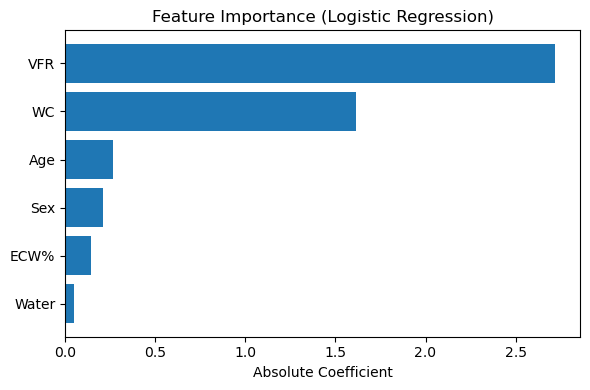

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, 
    accuracy_score, recall_score, f1_score, brier_score_loss
)

# 中文列名
features_zh = [ '身体水分量',  '细胞外液率', '内脏脂肪等级', 'XB0000','NL0000','腰围']
target = '脂肪肝'

# 英文映射
feature_map = {
   '身体水分量': 'Water','细胞外液率': 'ECW%', '内脏脂肪等级': 'VFR', 
    'XB0000': 'Sex', 'NL0000': 'Age' ,'腰围':'WC'
}

features_en = [feature_map[col] for col in features_zh]

# 数据读取与清洗
data = pd.read_excel(r"D:\NPAR\人体成分分析\最终试用版.xlsx")
df = data[features_zh + [target]].replace(['-----', '****', '***', '###', 'NA', 'NaN'], pd.NA)
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df[features_zh]
y = df[target]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_en)

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

# 逻辑回归 + 网格搜索
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
log_clf = LogisticRegression(max_iter=1000, random_state=42)
grid_search = GridSearchCV(estimator=log_clf, param_grid=param_grid,
                           scoring='roc_auc', cv=10, verbose=1, n_jobs=-1)

# 模型训练
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 模型预测
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 性能评估
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_prob)

print("最佳参数：", grid_search.best_params_)
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 提取逻辑回归系数作为特征重要性
coef = best_model.coef_.flatten()
importance_df = pd.DataFrame({
    'Feature_EN': X_train.columns,
    'Feature_ZH': [k for k, v in feature_map.items() if v in X_train.columns],
    'Coefficient': coef,
    'Importance': np.abs(coef)
}).sort_values(by='Importance', ascending=False)

# 保存为 Excel
importance_df.to_excel("Logistic_feature_importance.xlsx", index=False)

# 特征重要性图（按绝对值排序）
plt.figure(figsize=(6, 4))
plt.barh(importance_df['Feature_EN'], importance_df['Importance'])
plt.xlabel("Absolute Coefficient")
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Logistic_feature_importance_bar.png", dpi=600)
plt.show()


Fitting 10 folds for each of 8 candidates, totalling 80 fits
最佳参数： {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
AUC: 0.9635
Accuracy: 0.8986
Sensitivity (Recall): 0.8755
F1 Score: 0.8752
Brier Score: 0.0733
Confusion Matrix:
 [[3805  356]
 [ 354 2490]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      4161
           1       0.87      0.88      0.88      2844

    accuracy                           0.90      7005
   macro avg       0.89      0.89      0.89      7005
weighted avg       0.90      0.90      0.90      7005



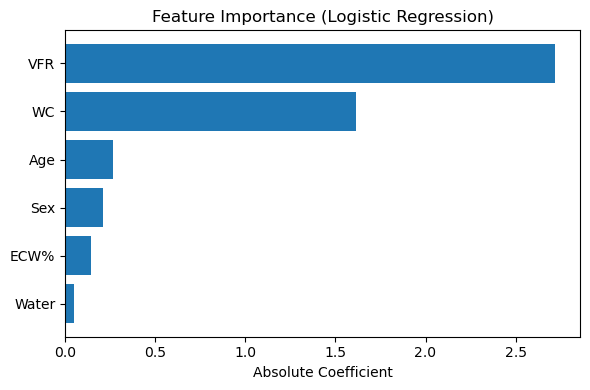

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, 
    accuracy_score, recall_score, f1_score, brier_score_loss
)

# 中文列名
features_zh = [ '身体水分量',  '细胞外液率', '内脏脂肪等级', 'XB0000','NL0000','腰围']
target = '脂肪肝'

# 英文映射
feature_map = {
   '身体水分量': 'Water','细胞外液率': 'ECW%', '内脏脂肪等级': 'VFR', 
    'XB0000': 'Sex', 'NL0000': 'Age' ,'腰围':'WC'
}

features_en = [feature_map[col] for col in features_zh]

# 数据读取与清洗
data = pd.read_excel(r"D:\NPAR\人体成分分析\最终试用版.xlsx")
df = data[features_zh + [target]].replace(['-----', '****', '***', '###', 'NA', 'NaN'], pd.NA)
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df[features_zh]
y = df[target]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_en)

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

# 逻辑回归 + 网格搜索
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
log_clf = LogisticRegression(max_iter=1000, random_state=42)
grid_search = GridSearchCV(estimator=log_clf, param_grid=param_grid,
                           scoring='roc_auc', cv=10, verbose=1, n_jobs=-1)

# 模型训练
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 模型预测
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 性能评估
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_prob)

print("最佳参数：", grid_search.best_params_)
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 提取逻辑回归系数作为特征重要性
coef = best_model.coef_.flatten()
importance_df = pd.DataFrame({
    'Feature_EN': X_train.columns,
    'Feature_ZH': [k for k, v in feature_map.items() if v in X_train.columns],
    'Coefficient': coef,
    'Importance': np.abs(coef)
}).sort_values(by='Importance', ascending=False)

# 保存为 Excel
importance_df.to_excel("Logistic_feature_importance腰围.xlsx", index=False)

# 特征重要性图（按绝对值排序）
plt.figure(figsize=(6, 4))
plt.barh(importance_df['Feature_EN'], importance_df['Importance'])
plt.xlabel("Absolute Coefficient")
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Logistic_feature_importance_bar腰围.png", dpi=600)
plt.show()
